In [19]:
import pandas as pd
import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

%matplotlib inline

In [20]:
df = pd.read_csv(r'Handicap Stats.csv')
df.head()

,Handicap,Avg Score to Par,Score by Hole Type - 3,Score by Hole Type - 4,Score by Hole Type - 5,FIR,FIR_Left,FIR_Right,Avg Drive Dist,GIR,...,GIR % 9i,GIR % PW,GIR % AW,GIR % SW,GIR % LW,Up Downs,Avg Proximity,Putts per Rd,Make Rate Inside 6ft,2 Putt Pct
0,20,23.2,4.0,5.4,6.4,0.479,0.233,0.281,218.8,0.154,...,0.250,0.348,0.418,0.422,0.470,0.298,19.9,32.6,0.837,0.605
1,19,21.9,4.0,5.3,6.3,0.481,0.236,0.278,221.7,0.169,...,0.267,0.357,0.432,0.436,0.476,0.309,19.4,32.4,0.840,0.605
2,18,20.7,3.9,5.3,6.2,0.482,0.239,0.275,224.6,0.184,...,0.285,0.366,0.445,0.450,0.483,0.320,18.9,32.3,0.844,0.605
3,17,19.4,3.9,5.2,6.1,0.483,0.242,0.272,227.6,0.201,...,0.302,0.376,0.458,0.464,0.490,0.331,18.4,32.1,0.848,0.604
4,16,18.2,3.8,5.1,6.0,0.484,0.245,0.269,230.5,0.218,...,0.319,0.386,0.472,0.478,0.498,0.342,18.0,32.0,0.852,0.604


In [21]:
print("\nDataset Information (columns, non-null counts, data types):")
df.info()

print("\nDescriptive Statistics for numerical columns:")
print(df.describe())


Dataset Information (columns, non-null counts, data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Handicap                35 non-null     int64  
 1   Avg Score to Par        35 non-null     float64
 2   Score by Hole Type - 3  35 non-null     float64
 3   Score by Hole Type - 4  35 non-null     float64
 4   Score by Hole Type - 5  35 non-null     float64
 5   FIR                     35 non-null     float64
 6   FIR_Left                35 non-null     float64
 7   FIR_Right               35 non-null     float64
 8   Avg Drive Dist          35 non-null     float64
 9   GIR                     35 non-null     float64
 10  GIR % Hyb               35 non-null     float64
 11  GIR % 4i                35 non-null     float64
 12  GIR % 5i                35 non-null     float64
 13  GIR % 6i                35 non-null 

**Starting the Model build-out**

REGRESSION SUMMARY:
Our model analyzed all features and determined that 'Avg Drive Dist' is the 
strongest mathematical predictor of your handicap. 

In layman's terms: If you could only improve one thing, moving the needle 
on 'Avg Drive Dist' provides the highest 'return on investment' for your score.


C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\3974425124.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Impact_Weight', y='Metric', palette='Blues_r')



--- GAP ANALYSIS (10 to 7 HCP) ---
                      Current_Avg  Target_Goal  Pct_Improvement_Needed
GIR                         0.342        0.415               21.345029
Up Downs                    0.415        0.455                9.638554
Avg Proximity              15.200       13.800                9.210526
Avg Drive Dist            248.000      256.700                3.508065
Make Rate Inside 6ft        0.878        0.893                1.708428
Putts per Rd               31.000       30.500                1.612903
FIR_Right                   0.257        0.254                1.167315
FIR                         0.491        0.495                0.814664
FIR_Left                    0.252        0.251                0.396825
2 Putt Pct                  0.603        0.602                0.165837

Visuals saved as: visual_1_drivers.png, visual_2_roadmap.png, visual_3_priority.png


C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\3974425124.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_df.reset_index(), x='Pct_Improvement_Needed', y='index', palette='Reds_r')


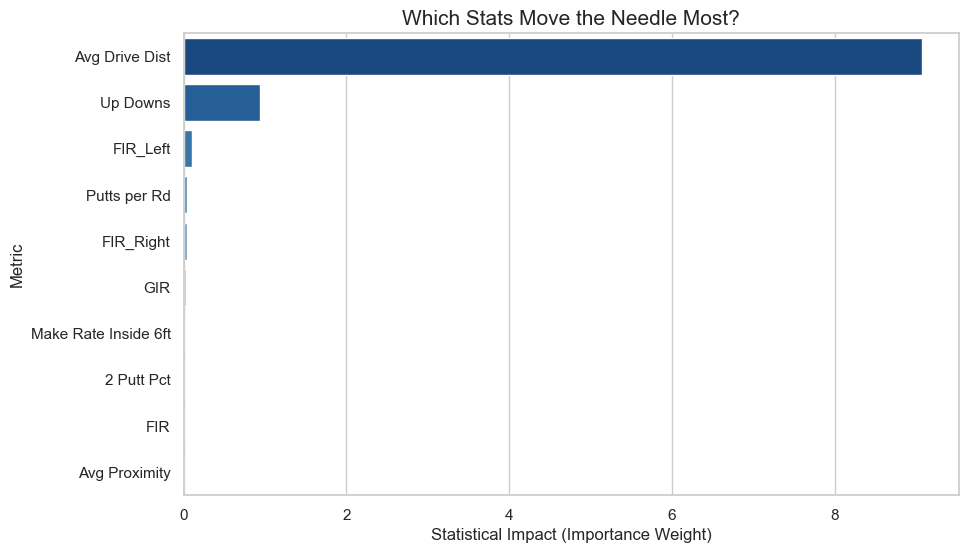

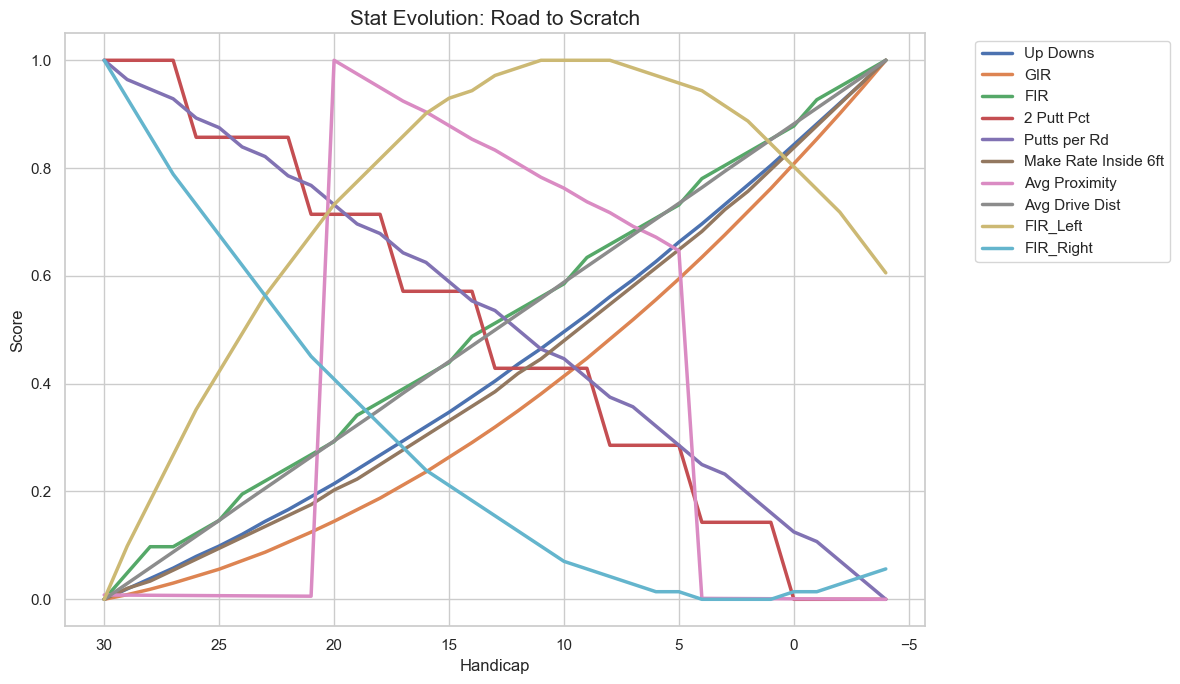

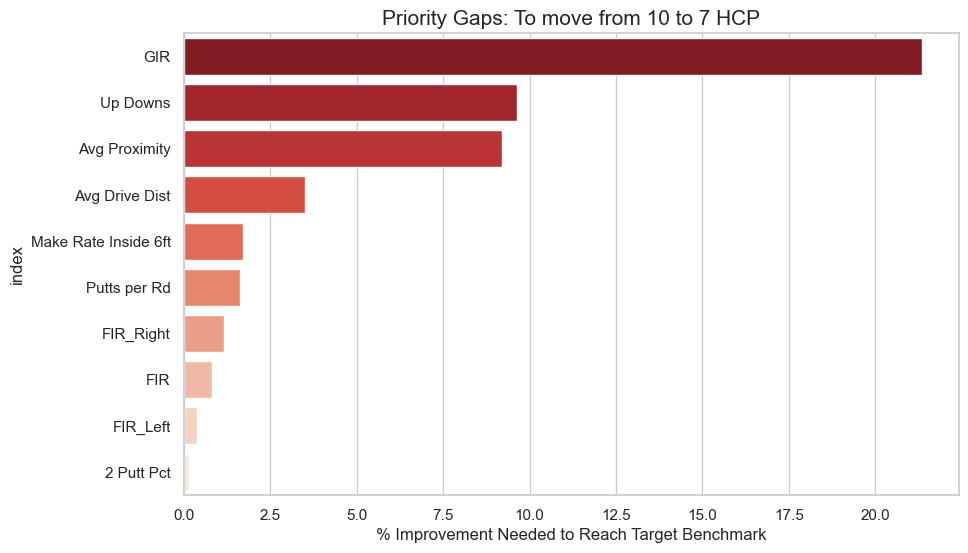

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
def load_and_clean_data(file_path):
    df = pd.read_csv(file_path)
    # Define primary KPIs for the golfer-facing model
    #kpi_cols = df.columns.drop(['Handicap','Avg Score to Par', 'Score by Hole Type - 3','Score by Hole Type - 4','Score by Hole Type - 5'])
    kpi_cols = ['Up Downs','GIR','FIR','2 Putt Pct','Putts per Rd','Make Rate Inside 6ft','Avg Proximity','Avg Drive Dist','FIR_Left','FIR_Right']
    return df, kpi_cols

# ==========================================
# 2. THE ENGINE: REGRESSION ANALYSIS
# ==========================================
def run_handicap_regression(df, kpi_cols):
    """
    Runs a regression to determine which stats have 
    the most 'weight' in lowering a handicap.
    """
    X = df[kpi_cols]
    y = df['Handicap']

    # Standardize features so we can compare coefficients directly
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression()
    model.fit(X_scaled, y)

    # Create Importance Table
    importance = pd.DataFrame({
        'Metric': kpi_cols,
        'Impact_Weight': np.abs(model.coef_)
    }).sort_values(by='Impact_Weight', ascending=False)
    
    return model, importance

def get_laymans_explanation(importance_df):
    """Generates a text-based explanation of the regression."""
    top_stat = importance_df.iloc[0]['Metric']
    explanation = (
        f"REGRESSION SUMMARY:\n"
        f"Our model analyzed all features and determined that '{top_stat}' is the \n"
        f"strongest mathematical predictor of your handicap. \n\n"
        f"In layman's terms: If you could only improve one thing, moving the needle \n"
        f"on '{top_stat}' provides the highest 'return on investment' for your score."
    )
    return explanation

# ==========================================
# 3. ANALYSIS LOGIC: GAP & RECOMMENDATION
# ==========================================
def analyze_golfer_gap(df, kpi_cols, current_hcp, target_hcp):
    """
    Compares a golfer's current level (or stats) 
    against the target handicap benchmark.
    """
    benchmarks = df.set_index('Handicap')
    
    if current_hcp not in benchmarks.index or target_hcp not in benchmarks.index:
        return None

    current_data = benchmarks.loc[current_hcp][kpi_cols]
    target_data = benchmarks.loc[target_hcp][kpi_cols]
    
    analysis = pd.DataFrame({
        'Current_Avg': current_data,
        'Target_Goal': target_data
    })
    
    # Calculate Gaps
    analysis['Absolute_Gap'] = analysis['Target_Goal'] - analysis['Current_Avg']
    # Use absolute percentage to see which area requires the most "growth"
    analysis['Pct_Improvement_Needed'] = (analysis['Absolute_Gap'] / analysis['Current_Avg']).abs() * 100
    
    return analysis.sort_values(by='Pct_Improvement_Needed', ascending=False)

# ==========================================
# 4. VISUALIZATION SUITE
# ==========================================
def create_visuals(df, kpi_cols, importance_df, gap_df, current_hcp, target_hcp):
    sns.set_theme(style="whitegrid")
    
    # Visual A: Impact Drivers (The 'Why')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Impact_Weight', y='Metric', palette='Blues_r')
    plt.title('Which Stats Move the Needle Most?', fontsize=15)
    plt.xlabel('Statistical Impact (Importance Weight)')
    plt.savefig('visual_1_drivers.png')
    
    # Visual B: The Evolution Roadmap (The 'Path')
    df_norm = df.copy()
    for col in kpi_cols:
        df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())
    
    df_melt = df_norm.melt(id_vars='Handicap', value_vars=kpi_cols, var_name='Stat', value_name='Score')
    
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df_melt, x='Handicap', y='Score', hue='Stat', linewidth=2.5)
    plt.gca().invert_xaxis() # Better golfers on the right (0 HCP)
    plt.title(f'Stat Evolution: Road to Scratch', fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('visual_2_roadmap.png')

    # Visual C: Individual Priority (The 'What')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=gap_df.reset_index(), x='Pct_Improvement_Needed', y='index', palette='Reds_r')
    plt.title(f'Priority Gaps: To move from {current_hcp} to {target_hcp} HCP', fontsize=15)
    plt.xlabel('% Improvement Needed to Reach Target Benchmark')
    plt.savefig('visual_3_priority.png')

# ==========================================
# 5. EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Setup
    CSV_FILE = 'Handicap Stats.csv'
    df, kpi_cols = load_and_clean_data(CSV_FILE)
    
    # 2. Run Engine
    model, importance_df = run_handicap_regression(df, kpi_cols)
    print(get_laymans_explanation(importance_df))
    
    # 3. Perform specific comparison (e.g. 10 to 7)
    CURR, TARGET = 10, 7
    gap_analysis = analyze_golfer_gap(df, kpi_cols, CURR, TARGET)
    
    # 4. Save Visuals
    create_visuals(df, kpi_cols, importance_df, gap_analysis, CURR, TARGET)
    
    print("\n--- GAP ANALYSIS (10 to 7 HCP) ---")
    print(gap_analysis[['Current_Avg', 'Target_Goal', 'Pct_Improvement_Needed']])
    print("\nVisuals saved as: visual_1_drivers.png, visual_2_roadmap.png, visual_3_priority.png")

In [23]:
CSV_FILE = 'Handicap Stats.csv'
df, kpi_cols = load_and_clean_data(CSV_FILE)

X = df[kpi_cols]
y = df['Handicap']

import statsmodels.api as sm
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Handicap   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.861e+06
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           2.21e-70
Time:                        14:32:44   Log-Likelihood:                 114.25
No. Observations:                  35   AIC:                            -206.5
Df Residuals:                      24   BIC:                            -189.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   88.7945 

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\172279808.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


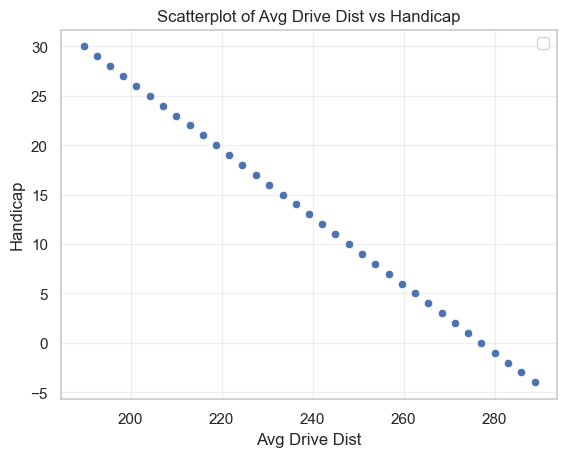

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\172279808.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


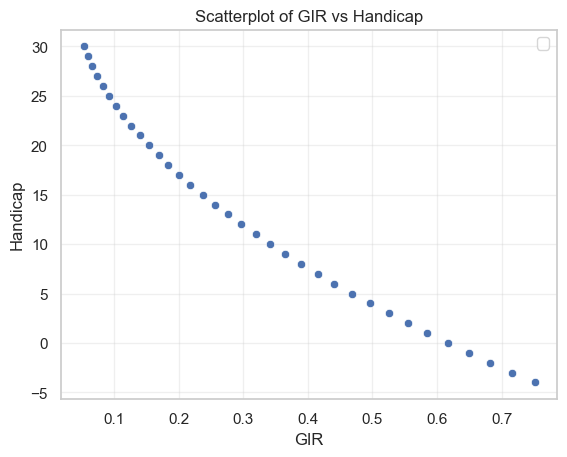

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\172279808.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


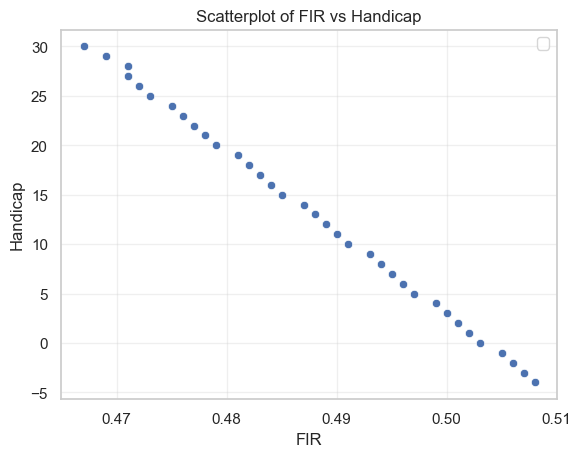

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\172279808.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


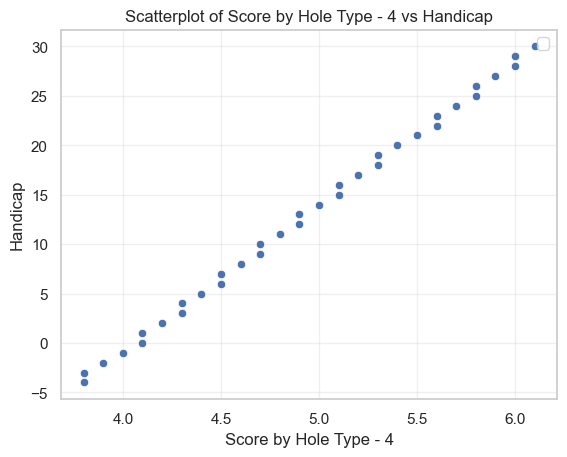

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_48832\172279808.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


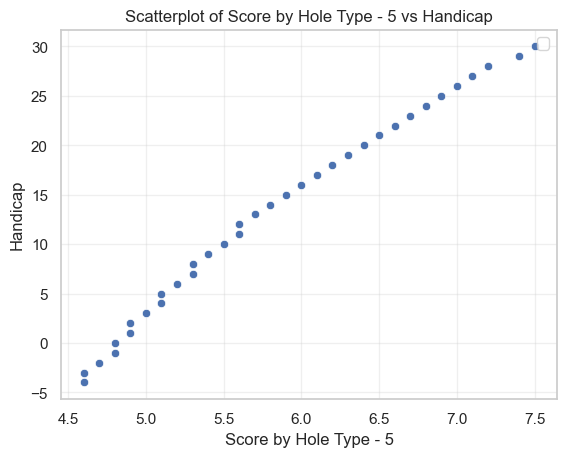

In [29]:
columns = ['Avg Drive Dist','GIR','FIR', 'Score by Hole Type - 4','Score by Hole Type - 5']

for col in columns:
    plt.tight_layout()
    sns.scatterplot(data = df, x=col, y='Handicap')
    plt.xlabel(col)
    plt.ylabel('Handicap')
    plt.title(f'Scatterplot of {col} vs Handicap')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [30]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def build_ridge_engine(csv_path):
    df = pd.read_csv(csv_path)

    # Use the 10 specific KPI columns for a balanced coaching model
    kpi_cols = [
        'Up Downs', 'GIR', 'FIR', '2 Putt Pct', 'Putts per Rd', 
        'Make Rate Inside 6ft', 'Avg Proximity', 'Avg Drive Dist', 
        'FIR_Left', 'FIR_Right'
    ]

    X = df[kpi_cols]
    y = df['Handicap']

    # 2. STANDARDIZE (Essential for Ridge)
    # This ensures that a 1-yard change isn't compared directly to a 1% change.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. TRAIN RIDGE MODEL
    # alpha=1.0 is the 'regularization' strength. 
    # It forces the model to share importance across correlated variables.
    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_scaled, y)

    # 4. EXTRACT FEATURE IMPORTANCE
    importance_df = pd.DataFrame({
        'Stat': kpi_cols,
        'Impact_Weight': ridge_model.coef_
    })
    
    # Sort by the magnitude of the impact
    importance_df['Absolute_Impact'] = importance_df['Impact_Weight'].abs()
    importance_df = importance_df.sort_values(by='Absolute_Impact', ascending=False)

    return ridge_model, scaler, importance_df, kpi_cols

# ==========================================
# 5. PREDICTION FUNCTION FOR WEBSITE
# ==========================================
def recommend_handicap(user_stats, model, scaler, kpi_cols):
    """
    Input: A dictionary of user stats { 'GIR': 0.35, 'Avg Drive Dist': 250, ... }
    Output: The predicted handicap based on the Ridge model.
    """
    # Convert dict to ordered list based on the model's training order
    input_data = [user_stats[col] for col in kpi_cols]
    
    # Scale the user data using the same scaler used for training
    input_scaled = scaler.transform([input_data])
    
    predicted_hcp = model.predict(input_scaled)[0]
    return round(predicted_hcp, 1)

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    MODEL_PATH = 'Handicap Stats.csv'
    model, scaler, importance, cols = build_ridge_engine(MODEL_PATH)

    print("--- COACHING IMPORTANCE RANKING (RIDGE) ---")
    print("Negative weights mean increasing the stat lowers your handicap.")
    print(importance[['Stat', 'Impact_Weight']].to_string(index=False))

    # Example: A user enters their stats to see their 'Predicted' Handicap
    sample_user = {
        'Up Downs': 0.40, 
        'GIR': 0.30, 
        'FIR': 0.50, 
        '2 Putt Pct': 0.60, 
        'Putts per Rd': 31.0, 
        'Make Rate Inside 6ft': 0.85, 
        'Avg Proximity': 16.0, 
        'Avg Drive Dist': 240.0, 
        'FIR_Left': 0.25, 
        'FIR_Right': 0.25
    }

    hcp_estimate = recommend_handicap(sample_user, model, scaler, cols)
    print(f"\nExample Prediction: This user plays like a {hcp_estimate} handicap.")

--- COACHING IMPORTANCE RANKING (RIDGE) ---
Negative weights mean increasing the stat lowers your handicap.
                Stat  Impact_Weight
                 GIR      -1.419602
Make Rate Inside 6ft      -1.389859
            Up Downs      -1.378789
        Putts per Rd       1.327104
      Avg Drive Dist      -1.324602
                 FIR      -1.296310
           FIR_Right       0.968889
          2 Putt Pct       0.850090
            FIR_Left      -0.360518
       Avg Proximity       0.019103

Example Prediction: This user plays like a 9.5 handicap.


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:

def generate_practice_plan(user_stats_dict, target_hcp, csv_path='Handicap Stats.csv'):
    # 1. Load Data and Train the Ridge Engine
    df = pd.read_csv(csv_path)
    kpi_cols = [
        'Up Downs', 'GIR', 'FIR', '2 Putt Pct', 'Putts per Rd', 
        'Make Rate Inside 6ft', 'Avg Proximity', 'Avg Drive Dist', 
        'FIR_Left', 'FIR_Right'
    ]
    
    X = df[kpi_cols]
    y = df['Handicap']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_scaled, y)
    weights = pd.Series(ridge.coef_, index=kpi_cols)
    
    # 2. Get Target Benchmarks
    target_row = df[df['Handicap'] == target_hcp]
    if target_row.empty:
        return f"Handicap {target_hcp} is outside our current database range."
    target_stats = target_row[kpi_cols].iloc[0]
    
    # 3. Standardize for Apples-to-Apples Comparison
    user_df = pd.DataFrame([user_stats_dict])[kpi_cols]
    target_df = pd.DataFrame([target_stats])[kpi_cols]
    
    user_scaled = scaler.transform(user_df)[0]
    target_scaled = scaler.transform(target_df)[0]
    
    # 4. Calculate Priority Scores
    results = []
    for i, col in enumerate(kpi_cols):
        weight = weights[col]
        
        # Calculate the standardized gap based on whether higher or lower is better
        # If weight is negative (e.g. GIR), higher stat is better -> Gap = Target - User
        # If weight is positive (e.g. Putts), lower stat is better -> Gap = User - Target
        if weight < 0:
            std_gap = target_scaled[i] - user_scaled[i]
        else:
            std_gap = user_scaled[i] - target_scaled[i]
        
        # Priority Score = (How far behind you are) x (How much that stat matters)
        # We use max(0, ...) because if you are already better than the target, priority is 0
        priority_score = max(0, std_gap * abs(weight))
        
        results.append({
            'Skill': col,
            'Your Stat': round(user_stats_dict[col], 3),
            'Target (Avg)': round(target_stats[col], 3),
            'Priority Score': round(priority_score, 2)
        })
    
    # 5. Return sorted plan
    return pd.DataFrame(results).sort_values(by='Priority Score', ascending=False)

# --- EXAMPLE USAGE ---
# If a user is a 15-handicapper and wants to reach 10:
my_stats = {
    'Up Downs': 0.353, 'GIR': 0.237, 'FIR': 0.485, '2 Putt Pct': 0.606, 
    'Putts per Rd': 31.8, 'Make Rate Inside 6ft': 0.856, 
    'Avg Proximity': 17.5, 'Avg Drive Dist': 233.4, 
    'FIR_Left': 0.244, 'FIR_Right': 0.264
}

plan = generate_practice_plan(my_stats, target_hcp=10)
print(plan.to_string(index=False))

               Skill  Your Stat  Target (Avg)  Priority Score
          2 Putt Pct      0.606         0.603            1.10
                 GIR      0.237         0.342            0.71
            Up Downs      0.353         0.415            0.69
Make Rate Inside 6ft      0.856         0.878            0.69
      Avg Drive Dist    233.400       248.000            0.66
                 FIR      0.485         0.491            0.64
        Putts per Rd     31.800        31.000            0.64
           FIR_Right      0.264         0.257            0.31
            FIR_Left      0.244         0.252            0.15
       Avg Proximity     17.500        15.200            0.01
